### Creating labeled dataset

In [1]:
# --- Import Libraries and Load Your Data ---
import pandas as pd
import numpy as np

# Load the features csv file
features_df = pd.read_csv("../outputs/comprehensive_features.csv")

# Load the cluster assignments csv file
cluster_map_df = pd.read_csv("../outputs/image_cluster_map.csv")


# --- Merge the DataFrames ---
# This combines the two files into a single master table using the 'image_id'
df_merged = pd.merge(features_df, cluster_map_df, on='image_id')


# --- Define and Create Descriptive Labels ---
# This map uses the integer labels from the clustering 
label_map = {
    -1: "Outlier / Anomaly",
    0: "Flat Edge, Raised Bed",
    1: "Gentle Slope Edge, Shallow Bed",
    2: "Flat Edge, Superficial bed",
    3: "Sloping Edge, Moderately Deep bed",
    4: "Elevated Bed",
    5: "Superficial Sharp and Uneven Edge",
    6: "Sharp and Textured Edge, Shallow bed"
}

# Create a new 'wound_type' column using the map.
df_merged['wound_type'] = df_merged['cluster_label'].map(label_map)


# --- Save Final Labeled Dataset ---
df_merged.to_csv("../outputs/features_with_labels.csv", index=False)

print("Labeled dataset created successfully!")
print("Here are the counts for each wound type:")
print(df_merged['wound_type'].value_counts())

Labeled dataset created successfully!
Here are the counts for each wound type:
wound_type
Sloping Edge, Moderately Deep bed       289
Sharp and Textured Edge, Shallow bed    220
Elevated Bed                            181
Flat Edge, Superficial bed              171
Gentle Slope Edge, Shallow Bed          143
Flat Edge, Raised Bed                    82
Superficial Sharp and Uneven Edge        33
Outlier / Anomaly                        24
Name: count, dtype: int64


### Build and Evaluate Predictive Model

Original number of rows: 1119
Number of rows after removing NaNs: 1119
Data split: Train samples = 895, Test samples = 224

Training the Random Forest model...
Training complete.

Overall Model Accuracy: 0.8259

Classification Report:
                                      precision    recall  f1-score   support

                        Elevated Bed       0.84      0.89      0.86        36
               Flat Edge, Raised Bed       0.89      1.00      0.94        16
          Flat Edge, Superficial bed       0.82      0.68      0.74        34
      Gentle Slope Edge, Shallow Bed       0.69      0.86      0.77        29
Sharp and Textured Edge, Shallow bed       0.81      0.89      0.85        44
   Sloping Edge, Moderately Deep bed       0.88      0.79      0.84        58
   Superficial Sharp and Uneven Edge       1.00      0.57      0.73         7

                            accuracy                           0.83       224
                           macro avg       0.85      0.81    

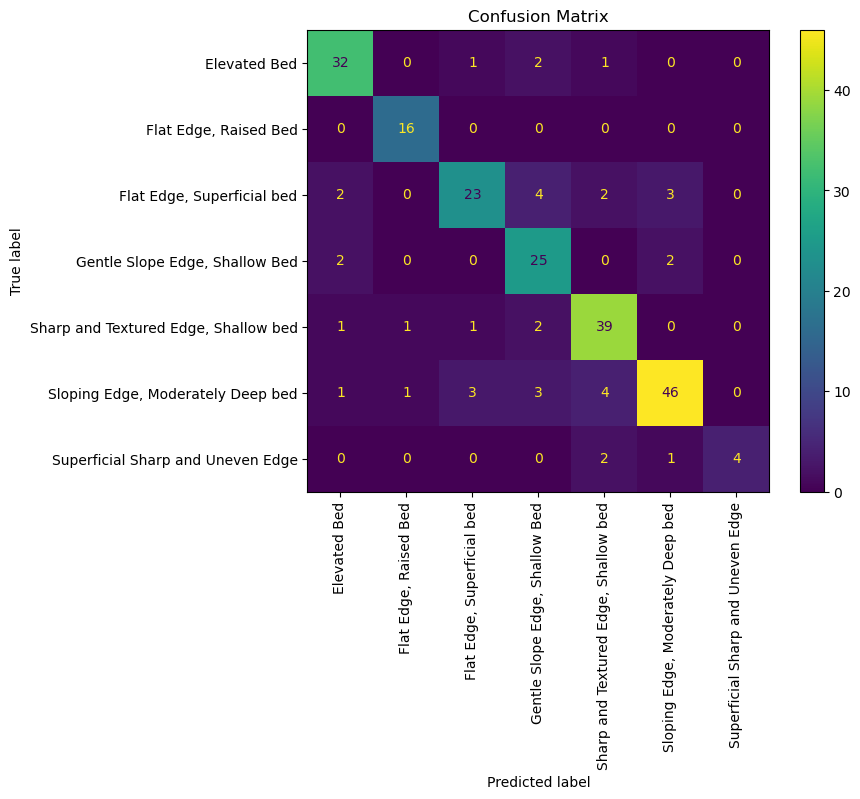

In [2]:
# --- Prepare for Supervised Learning ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Use the merged dataframe from the previous step
# filter out the 'Outliers' 
df_final = df_merged[df_merged['wound_type'] != 'Outlier / Anomaly'].copy()
print(f"Original number of rows: {len(df_final)}")

# The .dropna() function removes any row containing at least one NaN value.
df_final_cleaned = df_final.dropna()
print(f"Number of rows after removing NaNs: {len(df_final_cleaned)}")

# target 'y' is the descriptive wound type
y = df_final_cleaned['wound_type']

# features 'X' are all numerical columns. We drop the identifiers.
X = df_final_cleaned.drop(columns=['image_id', 'cluster_label', 'wound_type']) 


# ---Split the Data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data split: Train samples = {len(X_train)}, Test samples = {len(X_test)}")

# --- Train the Model ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nTraining the Random Forest model...")
rf_model.fit(X_train, y_train)
print("Training complete.")


# --- Evaluate Model Performance ---
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix")

# Save the figure for your report
output_path = "../report/fig/confusion_matrix.png"
plt.savefig(output_path, dpi=200, bbox_inches='tight')

plt.show()

### Analyze Feature Importance


Top 10 Most Important Features:
             feature  importance
7        edge_offset    0.076820
2             bed_r2    0.075758
18         edge_mean    0.068813
14          bed_mean    0.064740
1      bed_intercept    0.061533
4     edge_amplitude    0.060261
20         edge_skew    0.051178
6      edge_midpoint    0.046480
27  spectral_entropy    0.045548
12           skin_r2    0.043890


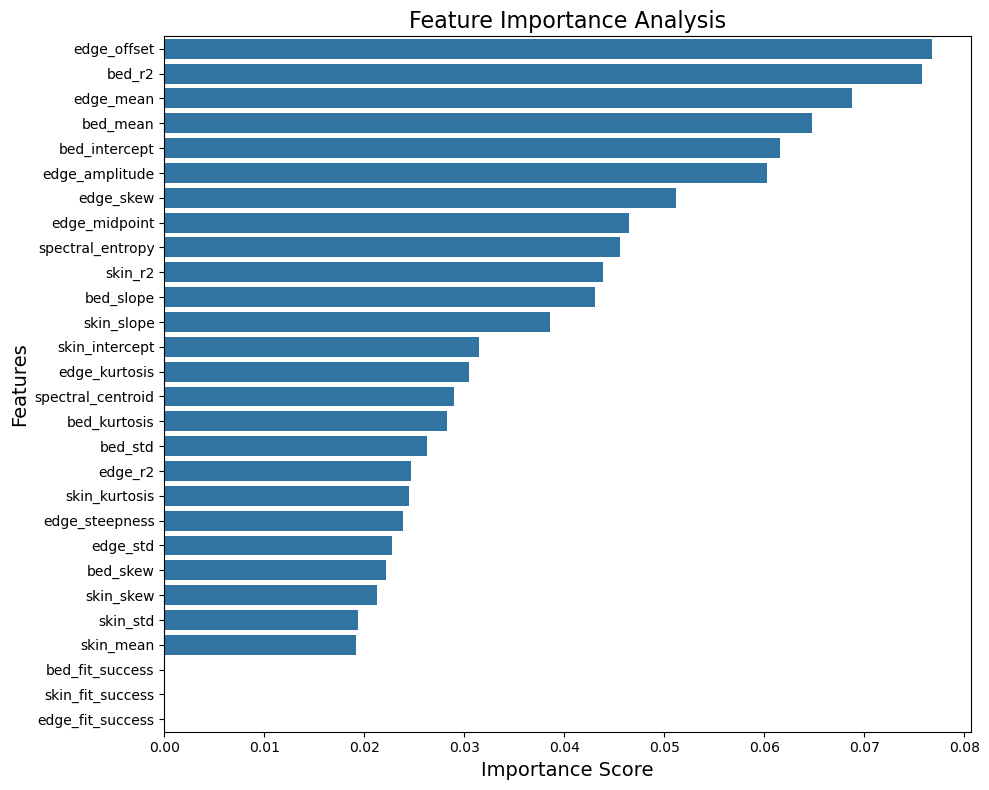

In [37]:
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance Analysis',fontsize=16)
plt.xlabel('Importance Score',fontsize=14)
plt.ylabel('Features',fontsize=14)
plt.tight_layout()
output_path = "../report/fig/gini_matric.png"
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()

In [4]:
from classification import label_and_save_clustered_data, prepare_training_data_splits, train_classifier, evaluate_classifier
df = pd.read_csv("../outputs/comprehensive_features.csv")
cluster_map = pd.read_csv("../outputs/image_cluster_map.csv")

df_merged = label_and_save_clustered_data(df,cluster_map)
X_train, X_test, y_train, y_test = prepare_training_data_splits(df_merged)
model = train_classifier(X_train,y_train)
evaluate_classifier(model, X_test, y_test,)

Labeled dataset created successfully!
Here are the counts for each wound type:
wound_type
Sloping Edge, Moderately Deep bed       289
Sharp and Textured Edge, Shallow bed    220
Elevated Bed                            181
Flat Edge, Superficial bed              171
Gentle Slope Edge, Shallow Bed          143
Flat Edge, Raised Bed                    82
Superficial Sharp and Uneven Edge        33
Outlier / Anomaly                        24
Name: count, dtype: int64
Original number of rows after filtering 'Outlier / Anomaly': 1119
Number of rows after removing NaNs: 1119
Prepared features (X) shape: (1119, 29), target (y) shape: (1119,)
Data split: Train samples = 895, Test samples = 224

Training RandomForest model...
Training complete.

Overall Model Accuracy: 0.9866

Classification Report:
                                      precision    recall  f1-score   support

                        Elevated Bed       0.97      1.00      0.99        36
               Flat Edge, Raised Bed      

{'accuracy': 0.9866071428571429,
 'classification_report': {'Elevated Bed': {'precision': 0.972972972972973,
   'recall': 1.0,
   'f1-score': 0.9863013698630136,
   'support': 36.0},
  'Flat Edge, Raised Bed': {'precision': 0.9411764705882353,
   'recall': 1.0,
   'f1-score': 0.9696969696969697,
   'support': 16.0},
  'Flat Edge, Superficial bed': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 34.0},
  'Gentle Slope Edge, Shallow Bed': {'precision': 1.0,
   'recall': 1.0,
   'f1-score': 1.0,
   'support': 29.0},
  'Sharp and Textured Edge, Shallow bed': {'precision': 0.9777777777777777,
   'recall': 1.0,
   'f1-score': 0.9887640449438202,
   'support': 44.0},
  'Sloping Edge, Moderately Deep bed': {'precision': 1.0,
   'recall': 0.9827586206896551,
   'f1-score': 0.991304347826087,
   'support': 58.0},
  'Superficial Sharp and Uneven Edge': {'precision': 1.0,
   'recall': 0.7142857142857143,
   'f1-score': 0.8333333333333334,
   'support': 7.0},
  'accuracy': 0.